# Lab 4

**Step 1 - Import Libraries**

In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2

from skimage.feature import hog
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import layers, models

**Step 2 - Load Dataset**

In [13]:
# Load images and labels from a directory structure
def load_dataset(img_dir):
    p = Path(img_dir)
    img_list = []
    for folder in p.glob('*'):
        label = folder.name
        for file in folder.glob('*.jpg'):
            img = cv2.imread(str(file))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_list.append((img, label))
    return img_list

train_dir = "images/training/"
test_dir  = "images/test/"

train_img = load_dataset(train_dir)
test_img  = load_dataset(test_dir)

In [16]:
print(len(train_img), len(test_img))


240 160


**Step 2 - Pre-processing**

Resize and label the data

In [14]:
# Preprocess images: resize and encode labels
def resize_image(img, size=(256,256)):
    return cv2.resize(img, size)

def label_encoder(label):
    return 1 if label == 'day' else 0

def preprocess(img_list):
    X = []
    y = []
    for img, label in img_list:
        img_std = resize_image(img)
        X.append(img_std)
        y.append(label_encoder(label))
    return X, y

X_train_img, y_train = preprocess(train_img)
X_test_img,  y_test  = preprocess(test_img)

**Step 3 - Feature Extraction**

Next, perform the feature extraction process. The feature to be used is HoG. Learn more about HoG at https://scikit-image.org/docs/0.25.x/auto_examples/features_detection/plot_hog.html

In [15]:
# Extract HOG features
def extract_hog(X_imgs):
    feats = []
    for img in X_imgs:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        hog_feat = hog(gray,
                       orientations=9,
                       pixels_per_cell=(8,8),
                       cells_per_block=(2,2),
                       block_norm='L2-Hys',
                       visualize=False,
                       feature_vector=True)
        feats.append(hog_feat)
    return np.array(feats)

X_train_feat = extract_hog(X_train_img)
X_test_feat  = extract_hog(X_test_img)

**Step 4 - Feature Standardization**

In [17]:
# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_test_scaled  = scaler.transform(X_test_feat)

**Step 5 - Create Training and Validation Data**

In [18]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.2,
    random_state=42
)

# Convert labels to numpy arrays
y_train = np.array(y_train)
y_val   = np.array(y_val)
y_test  = np.array(y_test)

**Step 6 - Construct the ANN Model**

The model architecture employed is,

- Input Layer 

- Hidden Layer 1 - 128 Nodes - ReLU

- Hidden Layer 2 - 64 Nodes - ReLU

- Output Layer - 2 Nodes - Sigmoid

In [19]:
input_dim = X_train.shape[1]

model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     4,428,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,436,737 (16.92 MB)

 Trainable params: 4,436,737 (16.92 MB)

 Non-trainable params: 0 (0.00 B)

**Step 7 - Train the Model**

In [20]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.8021 - loss: 0.9220 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9844 - loss: 0.0748 - val_accuracy: 1.0000 - val_loss: 7.5431e-05
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 2.3552e-05
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9948 - loss: 0.0118 - val_accuracy: 1.0000 - val_loss: 6.6471e-05
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 1.0000 - loss: 2.6191e-06 - val_accuracy: 1.0000 - val_loss: 9.8982e-05
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 1.0000 - loss: 5.8104e-06 - val_accuracy: 1.0000 - val_loss: 1.2101e-04
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 1.0000 - loss: 1.0787e-05 - val_accuracy: 1.0000 - val_loss: 1.3361e-04
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 1.0000 - loss: 1.0337e-05 

You can subsequently access the model's performance using the variable history that was created.

**Step 8 - Evaluate the Model with Test Data**

In [21]:
test_loss, test_acc = model.evaluate(X_test_scaled, y_test)
print("Test Accuracy:", test_acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8938 - loss: 1.1440
Test Accuracy: 0.893750011920929


**Step 9 - Generate a Model Performance Report**

In [22]:
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
              precision    recall  f1-score   support

           0       0.86      0.94      0.90        80
           1       0.93      0.85      0.89        80

    accuracy                           0.89       160
   macro avg       0.90      0.89      0.89       160
weighted avg       0.90      0.89      0.89       160

[[75  5]
 [12 68]]


**Step 10 - Visualize the Training Process**

This visualization is important for monitoring model performance. The visualization employs the Receiver Operating Characteristic (ROC) concept to assess model performance across epochs.

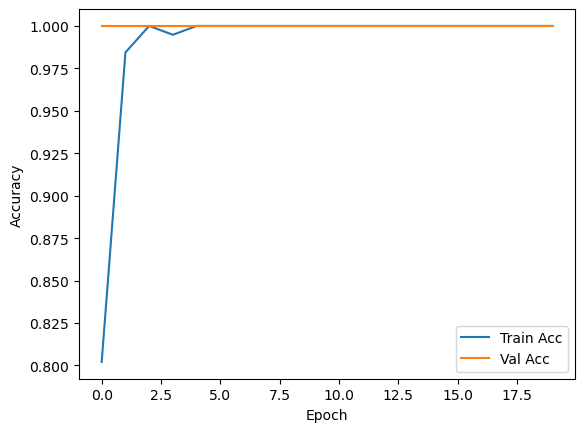

In [24]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

From that plot, what can you interpret?

The model quickly reaches 100% accuracy on both training and validation data, meaning it learns and fits them very easily. However, the test accuracy drops to about 89%, showing that the model doesn’t generalize as well to new data. This gap indicates mild overfitting. The model performs perfectly on the data it has seen during training and validation but is less accurate when evaluated on unseen samples.

**Step 11 - Save the Model**

Save the model for production purposes.

In [25]:
model.save('day_night_classifier_model.h5')